In [1]:
pip install tensorflow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)

In [18]:
import tensorflow as tf

IMG_SIZE = (28, 28)
BATCH_SIZE = 128

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "archive/mnist_png/training",
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "archive/mnist_png/testing",
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


In [20]:
def normalize(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images

train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

In [22]:
def add_noise(images):
    noise = tf.random.normal(
        shape=tf.shape(images),
        mean=0.0,
        stddev=0.5
    )

    noisy = images + noise
    noisy = tf.clip_by_value(noisy, 0.0, 1.0)

    return noisy, images

In [24]:
train_dataset = train_dataset.map(add_noise)
test_dataset = test_dataset.map(add_noise)

In [26]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32,3,activation='relu',padding='same')(input_img)
x = MaxPooling2D(2,padding='same')(x)

x = Conv2D(16,3,activation='relu',padding='same')(x)
encoded = MaxPooling2D(2,padding='same')(x)

# Decoder
x = Conv2D(16,3,activation='relu',padding='same')(encoded)
x = UpSampling2D(2)(x)

x = Conv2D(32,3,activation='relu',padding='same')(x)
x = UpSampling2D(2)(x)

decoded = Conv2D(
    1,
    3,
    activation='sigmoid',
    padding='same'
)(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 16)            │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = autoencoder.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - loss: 0.1904 - val_loss: 0.1265
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.1218 - val_loss: 0.1163
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.1150 - val_loss: 0.1114
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 0.1110 - val_loss: 0.1084
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 0.1085 - val_loss: 0.1066
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 0.1068 - val_loss: 0.1054
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.1057 - val_loss: 0.1038
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.1046 - val_loss: 0.1034
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.1039 - val_loss: 0.1028
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.1032 - val_loss: 0.1021
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.1026 - val_loss: 0.1013
Epoch 12/20
469/469 ━━━━━━━━━━

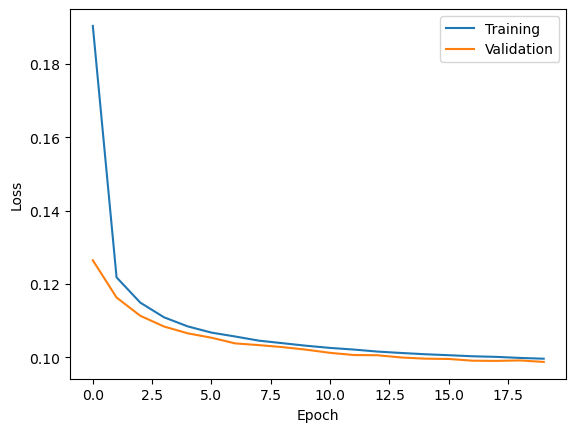

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Training','Validation'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


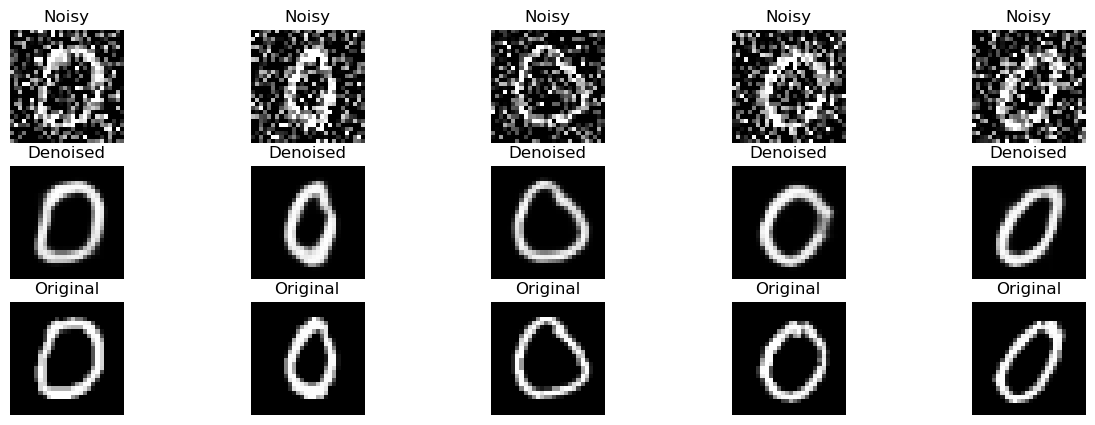

In [32]:
for noisy, clean in test_dataset.take(1):
    prediction = autoencoder.predict(noisy)

    plt.figure(figsize=(15,5))

    for i in range(5):

        plt.subplot(3,5,i+1)
        plt.imshow(noisy[i].numpy().squeeze(), cmap='gray')
        plt.axis('off')
        plt.title("Noisy")

        plt.subplot(3,5,i+6)
        plt.imshow(prediction[i].squeeze(), cmap='gray')
        plt.axis('off')
        plt.title("Denoised")

        plt.subplot(3,5,i+11)
        plt.imshow(clean[i].numpy().squeeze(), cmap='gray')
        plt.axis('off')
        plt.title("Original")

    plt.show()

In [34]:
autoencoder.save("mnist_denoising_autoencoder.keras")

In [36]:
loss = autoencoder.evaluate(test_dataset)

print("Test Loss:", loss)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0988
Test Loss: 0.09879539161920547


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


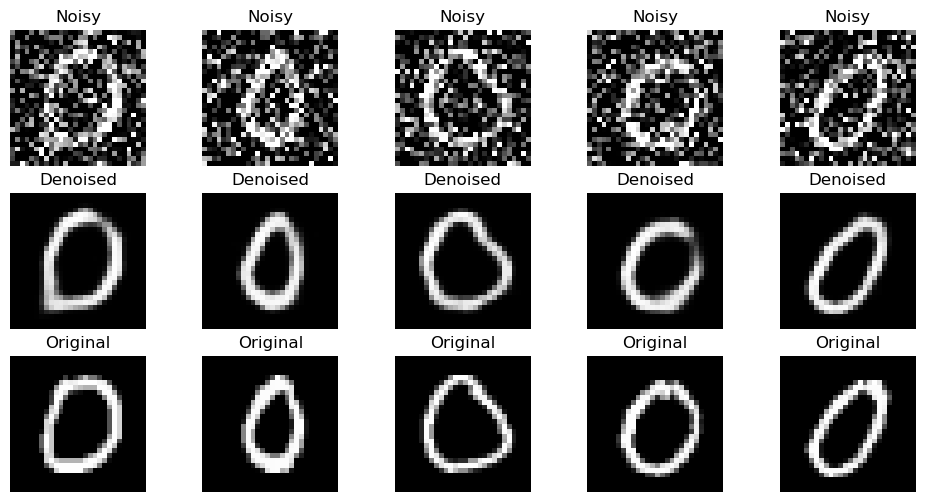

In [38]:
for noisy, clean in test_dataset.take(1):
    pred = autoencoder.predict(noisy)

    plt.figure(figsize=(12,6))

    for i in range(5):

        plt.subplot(3,5,i+1)
        plt.imshow(noisy[i].numpy().squeeze(), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(3,5,i+6)
        plt.imshow(pred[i].squeeze(), cmap="gray")
        plt.title("Denoised")
        plt.axis("off")

        plt.subplot(3,5,i+11)
        plt.imshow(clean[i].numpy().squeeze(), cmap="gray")
        plt.title("Original")
        plt.axis("off")

    plt.savefig("denoising_results.png")
    plt.show()